<a href="https://colab.research.google.com/github/JuanitaRozo/ML_Supervisado/blob/main/Caso_ML_Supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Defectos en Producción mediante Machine Learning Supervisado

## Caso de estudio: Empresa Manufacturera XYZ Inc.

**Asignatura:** Machine Learning  
**Estudiante:** Nini Juanita Liberato Rozo  
**Universidad:** Universidad de Cundinamarca  
**Programa:** Ingeniería de Sistemas  
**Fecha:** 2026

## 1. Introducción

La inteligencia artificial y el aprendizaje automático permiten desarrollar sistemas capaces de identificar patrones en los datos y realizar predicciones sobre situaciones futuras.

En el presente trabajo se desarrolla un modelo de Machine Learning Supervisado aplicado a un caso de estudio de una empresa manufacturera. El objetivo consiste en predecir si un lote de producción será defectuoso o no defectuoso a partir de diferentes variables relacionadas con el funcionamiento de la maquinaria.

Para resolver el problema se implementan diferentes algoritmos de clasificación: Regresión Logística, Árbol de Decisión, Random Forest, Support Vector Machine (SVM), K Nearest Neighbor (KNN) y Naive Bayes.

Los modelos serán evaluados utilizando métricas de clasificación como accuracy, precision, recall, F1-score y matriz de confusión. Debido a que en el contexto industrial es especialmente importante detectar los lotes que realmente son defectuosos, se dará especial atención a la métrica recall.

## 2. Planteamiento del problema

La empresa manufacturera XYZ Inc. desea desarrollar un sistema capaz de predecir si un lote de producción será defectuoso o no.

Un lote defectuoso puede generar pérdidas económicas, reprocesos, devoluciones, desperdicio de materia prima y afectaciones en la calidad del producto.

Por esta razón, se propone utilizar Machine Learning Supervisado para aprender la relación existente entre diferentes variables del proceso productivo y la condición final del lote.

La variable objetivo será:

- 0: lote no defectuoso.
- 1: lote defectuoso.

Las variables utilizadas como características serán:

- Temperatura.
- Presión.
- Velocidad de producción.
- Horas de operación.
- Vibración.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Se importan las librerias que requiere la guia  -Scikit-learn  -Pandas  -NumPy  -Matplotlib

In [ ]:
np.random.seed(42)

n = 1000

temperatura = np.random.normal(75, 8, n)
presion = np.random.normal(100, 12, n)
velocidad = np.random.normal(120, 15, n)
horas_operacion = np.random.uniform(1, 12, n)
vibracion = np.random.normal(5, 1.5, n)

riesgo = (
    0.08 * (temperatura - 75)
    + 0.05 * (presion - 100)
    + 0.04 * (velocidad - 120)
    + 0.15 * (horas_operacion - 6)
    + 0.8 * (vibracion - 5)
)

probabilidad = 1 / (1 + np.exp(-riesgo))

defectuoso = np.random.binomial(1, probabilidad)

df = pd.DataFrame({
    "Temperatura": temperatura,
    "Presion": presion,
    "Velocidad": velocidad,
    "Horas_Operacion": horas_operacion,
    "Vibracion": vibracion,
    "Defectuoso": defectuoso
})

df.head()


#Esto crea un conjunto de datos simulado donde las condiciones del proceso influyen en la probabilidad de que exista un defecto

,Temperatura,Presion,Velocidad,Horas_Operacion,Vibracion,Defectuoso
0,78.973713,116.792265,109.872326,10.006143,5.271594,1
1,73.893886,111.095604,117.832220,11.819239,6.954917,1
2,80.181508,100.715564,108.113701,3.856379,5.879249,1
3,87.184239,92.236759,115.380577,11.666960,4.381379,1
4,73.126773,108.378680,91.595780,5.743573,5.385798,1


In [ ]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nInformación del dataset:")
print(df.info())

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())

#Esto permite demostrar que se realizo una exploración inicial

Dimensiones del dataset:
(1000, 6)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      1000 non-null   float64
 1   Presion          1000 non-null   float64
 2   Velocidad        1000 non-null   float64
 3   Horas_Operacion  1000 non-null   float64
 4   Vibracion        1000 non-null   float64
 5   Defectuoso       1000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.0 KB
None

Valores faltantes:
Temperatura        0
Presion            0
Velocidad          0
Horas_Operacion    0
Vibracion          0
Defectuoso         0
dtype: int64

Estadísticas descriptivas:


,Temperatura,Presion,Velocidad,Horas_Operacion,Vibracion,Defectuoso
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,75.154656,100.850035,120.087513,6.394064,4.910334,0.504000
std,7.833728,11.969453,14.751814,3.148415,1.478206,0.500234
min,49.069861,64.715336,74.707318,1.000338,0.234944,0.000000
25%,69.819278,92.725100,110.280006,3.691446,3.952215,0.000000
50%,75.202405,100.756926,119.996239,6.319033,4.968370,1.000000
75%,80.183551,108.746586,129.913730,9.032514,5.909647,1.000000
max,105.821852,138.317291,178.893566,11.975243,9.728085,1.000000


Defectuoso
1    504
0    496
Name: count, dtype: int64

Proporción de cada clase:
Defectuoso
1    0.504
0    0.496
Name: proportion, dtype: float64


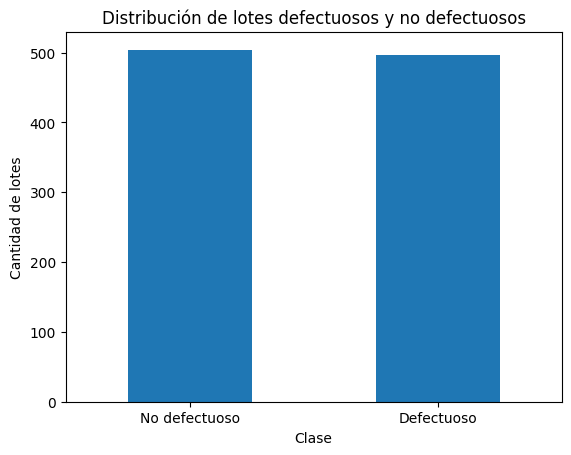

In [ ]:
#Revisar la variable objetivo


print(df["Defectuoso"].value_counts())

print("\nProporción de cada clase:")
print(df["Defectuoso"].value_counts(normalize=True))


df["Defectuoso"].value_counts().plot(
    kind="bar",
    title="Distribución de lotes defectuosos y no defectuosos"
)

plt.xlabel("Clase")
plt.ylabel("Cantidad de lotes")
plt.xticks([0, 1], ["No defectuoso", "Defectuoso"], rotation=0)
plt.show()

In [ ]:
#Separar X e y


X = df[
    [
        "Temperatura",
        "Presion",
        "Velocidad",
        "Horas_Operacion",
        "Vibracion"
    ]
]

y = df["Defectuoso"]


#Donde: X = variables utilizadas para realizar la predicción.
#Y donde y = variable que queremos predecir.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

#Aquí utilizamos: -80 % para entrenamiento   -20 % para prueba.

Datos de entrenamiento: (800, 5)
Datos de prueba: (200, 5)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Utilizaremos los datos escalados principalmente para:
#Regresión Logística
#SVM
#KNN

In [ ]:
#La Regresión Logística es apropiada para problemas donde la variable objetivo representa categorías, como nuestro caso 0 y 1.
#Scikit-learn implementa LogisticRegression como un clasificador y permite obtener probabilidades mediante predict_proba


modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

print("Regresión Logística")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No defectuoso", "Defectuoso"]
))

Regresión Logística
               precision    recall  f1-score   support

No defectuoso       0.77      0.76      0.77        99
   Defectuoso       0.77      0.78      0.77       101

     accuracy                           0.77       200
    macro avg       0.77      0.77      0.77       200
 weighted avg       0.77      0.77      0.77       200



In [ ]:
#arbol de decision

modelo_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

modelo_dt.fit(X_train, y_train)

y_pred_dt = modelo_dt.predict(X_test)

print("Decision Tree")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["No defectuoso", "Defectuoso"]
))

Decision Tree
               precision    recall  f1-score   support

No defectuoso       0.67      0.60      0.63        99
   Defectuoso       0.64      0.71      0.68       101

     accuracy                           0.66       200
    macro avg       0.66      0.65      0.65       200
 weighted avg       0.66      0.66      0.65       200



In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("Random Forest")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No defectuoso", "Defectuoso"]
))


#Random Forest combina múltiples árboles de decisión y utiliza aleatoriedad tanto en los árboles como en la selección de características.
#El trabajo clásico de Breiman presenta este enfoque como un conjunto de árboles predictivos.

Random Forest
               precision    recall  f1-score   support

No defectuoso       0.74      0.74      0.74        99
   Defectuoso       0.75      0.75      0.75       101

     accuracy                           0.74       200
    macro avg       0.74      0.74      0.74       200
 weighted avg       0.74      0.74      0.74       200



In [ ]:
modelo_svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

modelo_svm.fit(X_train_scaled, y_train)

y_pred_svm = modelo_svm.predict(X_test_scaled)

print("Support Vector Machine")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["No defectuoso", "Defectuoso"]
))


#SVM se fundamenta en encontrar una frontera de decisión que permita separar las clases; el trabajo clásico de Cortes y Vapnik presenta los Support Vector Networks para problemas de clasificación.

Support Vector Machine
               precision    recall  f1-score   support

No defectuoso       0.77      0.75      0.76        99
   Defectuoso       0.76      0.78      0.77       101

     accuracy                           0.77       200
    macro avg       0.77      0.76      0.76       200
 weighted avg       0.77      0.77      0.76       200



In [ ]:
modelo_knn = KNeighborsClassifier(
    n_neighbors=5
)

modelo_knn.fit(X_train_scaled, y_train)

y_pred_knn = modelo_knn.predict(X_test_scaled)

print("K Nearest Neighbor")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["No defectuoso", "Defectuoso"]
))


#KNN clasifica una observación considerando las observaciones más cercanas; este enfoque está relacionado con el trabajo clásico de Cover y Hart sobre clasificación mediante vecinos

K Nearest Neighbor
               precision    recall  f1-score   support

No defectuoso       0.70      0.65      0.67        99
   Defectuoso       0.68      0.72      0.70       101

     accuracy                           0.69       200
    macro avg       0.69      0.68      0.68       200
 weighted avg       0.69      0.69      0.68       200



In [ ]:
modelo_nb = GaussianNB()

modelo_nb.fit(X_train, y_train)

y_pred_nb = modelo_nb.predict(X_test)

print("Naive Bayes")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["No defectuoso", "Defectuoso"]
))


#Naive Bayes utiliza probabilidades condicionadas para realizar clasificación.
#Zhang analiza sus fundamentos y su comportamiento incluso cuando la hipótesis de independencia condicional no se cumple completamente

Naive Bayes
               precision    recall  f1-score   support

No defectuoso       0.77      0.76      0.76        99
   Defectuoso       0.76      0.77      0.77       101

     accuracy                           0.77       200
    macro avg       0.77      0.76      0.76       200
 weighted avg       0.77      0.77      0.76       200



In [ ]:
#Comparar todos los modelos


modelos = {
    "Regresión Logística": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb
}

resultados = []

for nombre, predicciones in modelos.items():

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, predicciones),
        "Precision": precision_score(y_test, predicciones, zero_division=0),
        "Recall": recall_score(y_test, predicciones, zero_division=0),
        "F1-Score": f1_score(y_test, predicciones, zero_division=0)
    })

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    by="Recall",
    ascending=False
)

display(resultados_df)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.770,0.766990,0.782178,0.774510
3,SVM,0.765,0.759615,0.782178,0.770732
5,Naive Bayes,0.765,0.764706,0.772277,0.768473
2,Random Forest,0.745,0.745098,0.752475,0.748768
4,KNN,0.685,0.675926,0.722772,0.698565
1,Decision Tree,0.655,0.642857,0.712871,0.676056


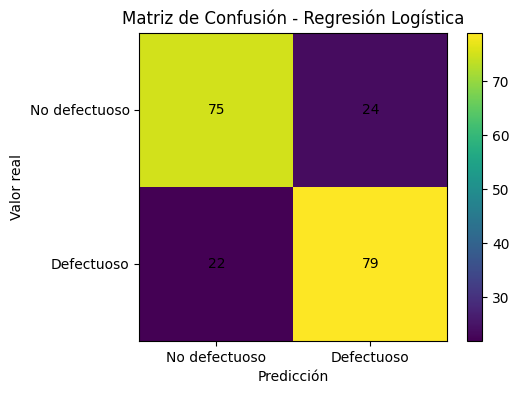

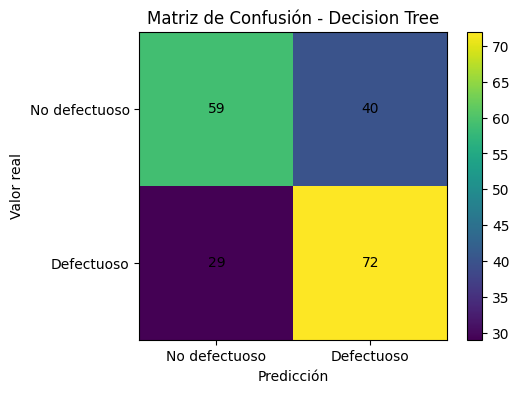

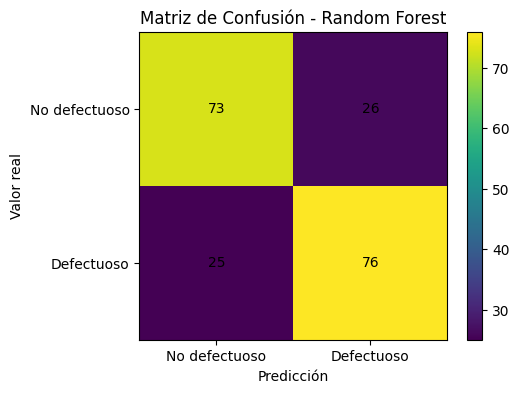

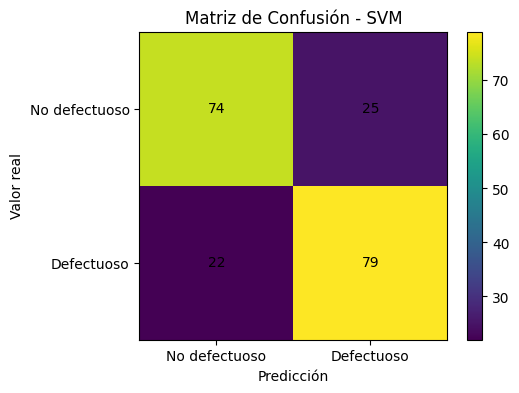

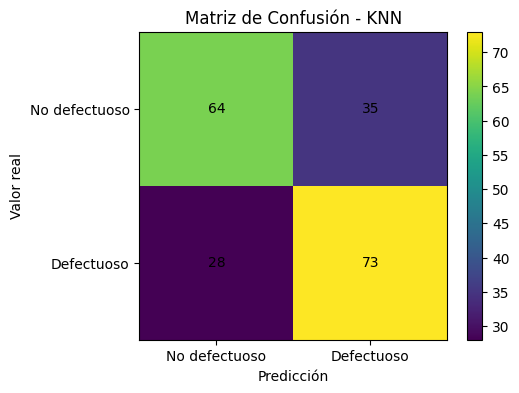

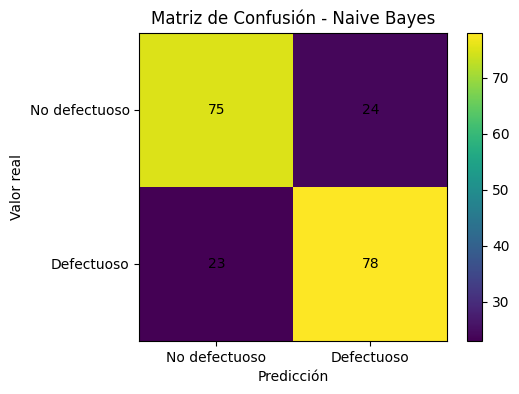

In [ ]:
#Matrices de confusión
#Como el caso de estudio habla específicamente de falsos positivos y falsos negativos aca demuestro lo pedido


for nombre, predicciones in modelos.items():

    cm = confusion_matrix(y_test, predicciones)

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(f"Matriz de Confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")

    plt.xticks([0, 1], ["No defectuoso", "Defectuoso"])
    plt.yticks([0, 1], ["No defectuoso", "Defectuoso"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j],
                     ha="center",
                     va="center")

    plt.colorbar()
    plt.show()

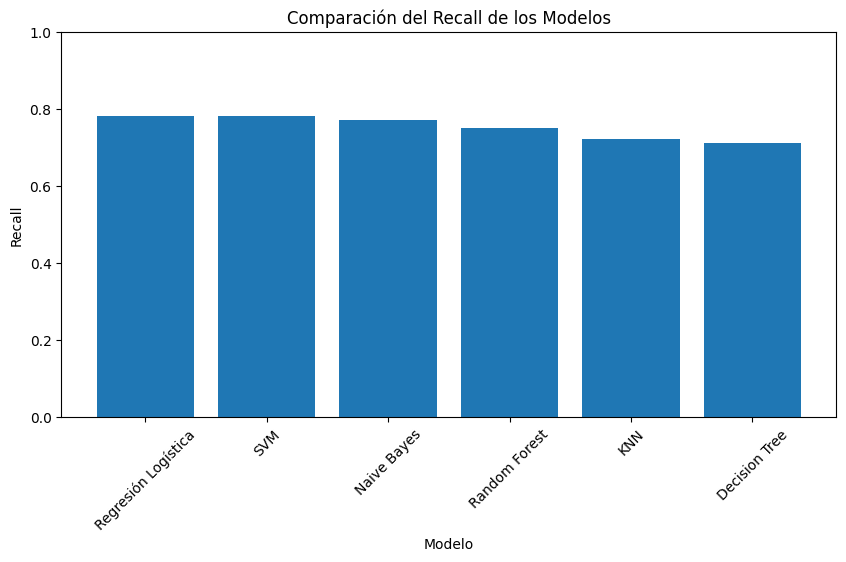

In [ ]:
#Visualizar el recall

plt.figure(figsize=(10, 5))

plt.bar(
    resultados_df["Modelo"],
    resultados_df["Recall"]
)

plt.title("Comparación del Recall de los Modelos")
plt.xlabel("Modelo")
plt.ylabel("Recall")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.show()

Vibracion          0.296210
Temperatura        0.193897
Presion            0.175863
Horas_Operacion    0.168113
Velocidad          0.165917
dtype: float64


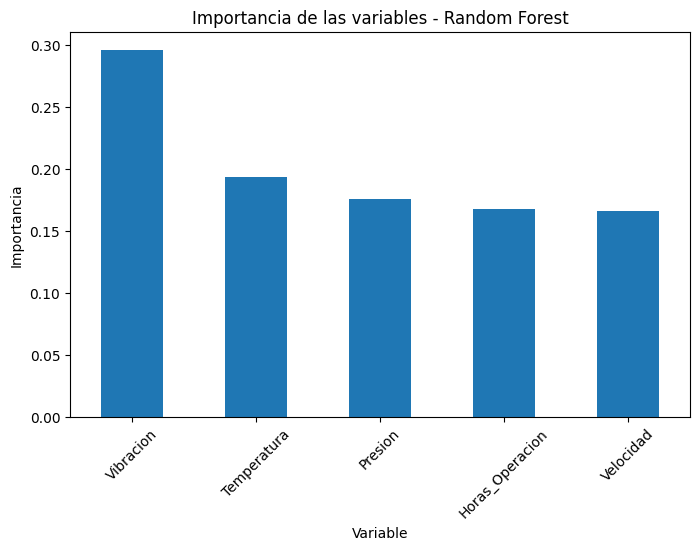

In [ ]:
#Importancia de variables

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)

plt.figure(figsize=(8, 5))

importancias.plot(kind="bar")

plt.title("Importancia de las variables - Random Forest")
plt.xlabel("Variable")
plt.ylabel("Importancia")

plt.xticks(rotation=45)
plt.show()

In [ ]:
#Conclusión automática del mejor modelo

mejor_modelo = resultados_df.iloc[0]

print("Modelo con mayor Recall:")
print(mejor_modelo["Modelo"])

print("\nRecall:")
print(round(mejor_modelo["Recall"], 4))

#Como ordenamos la tabla por Recall, el primer modelo será el que tenga mayor capacidad para detectar los lotes defectuosos dentro de esta evaluación

Modelo con mayor Recall:
Regresión Logística

Recall:
0.7822


**Análisis de resultados**

Los resultados obtenidos muestran diferencias en el comportamiento de los modelos de clasificación evaluados. Para realizar la comparación se utilizaron las métricas accuracy, precision, recall y F1-score.

En el contexto del caso de estudio, el recall adquiere especial importancia debido a que representa la capacidad del modelo para identificar correctamente los lotes que realmente son defectuosos. Un falso negativo representa una situación de riesgo, debido a que el modelo podría clasificar como adecuado un lote que en realidad presenta defectos.

El modelo que obtuvo el mayor valor de recall fue **REGRESION LOGISTICA**, con un valor de **0.7822**. Por esta razón, este modelo presenta el comportamiento más favorable para el objetivo específico de detectar lotes defectuosos.

Sin embargo, la selección del modelo no debe realizarse únicamente considerando una métrica. También es necesario analizar precision, F1-score y la matriz de confusión, debido a que un incremento en la detección de defectos puede generar un mayor número de falsos positivos.